## ECS 171 Homework 1

Please explain your solutions clearly and include your entire computational work when needed. Should you include any code, please make sure to provide additional comments to explain your solution. Please put your work/solution for each question after the corresponding horizontal line in a separate coding or markdown box. Feel free to add coding or markdown boxes as you see fit. Usage of the numpy, pandas, seaborn, matplotlib and sklearn libraries are allowed.

### Question 1 (Outliers)- (5 points)
How does the presence of outliers influence the choice between using covariance and correlation to analyze the relationship between two variables in a dataset? Explain how each measure handles outliers differently and discuss the implications for interpreting their results in practical applications.
***
**_Answer Question 1:_**
Covariance and correlation metrics are two parameters that are defined between random variables to analyze the relationship between them. Covariance is a measure of how two variables X and Y change together linearly given a population size n. Covariance measures the directional relationship between X and Y and can't show the strength of the relationship between the two variables (We use the Pearsons correlation coefficient for linear relationships and Spearman's correlation coefficient for nonlinear relationships). Covariance is also sensitive to the presence of outliers. Correlation on the other hand measures the strength and direction of a linear relationship and is less susceptible to outliers. Conclusively speaking, when dealing with outliers in a dataset correlation coefficients are a more robust definition to use for quantifying a relationship between variabeles X and Y considering that their less effected by outliers compared to covariance.


***


### Question 2 (EDA)- (25 points)
The following code provides the distribution of the attributes of the breast cancer dataset from sklearn library. 


<bound method NDFrame.head of      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean conca

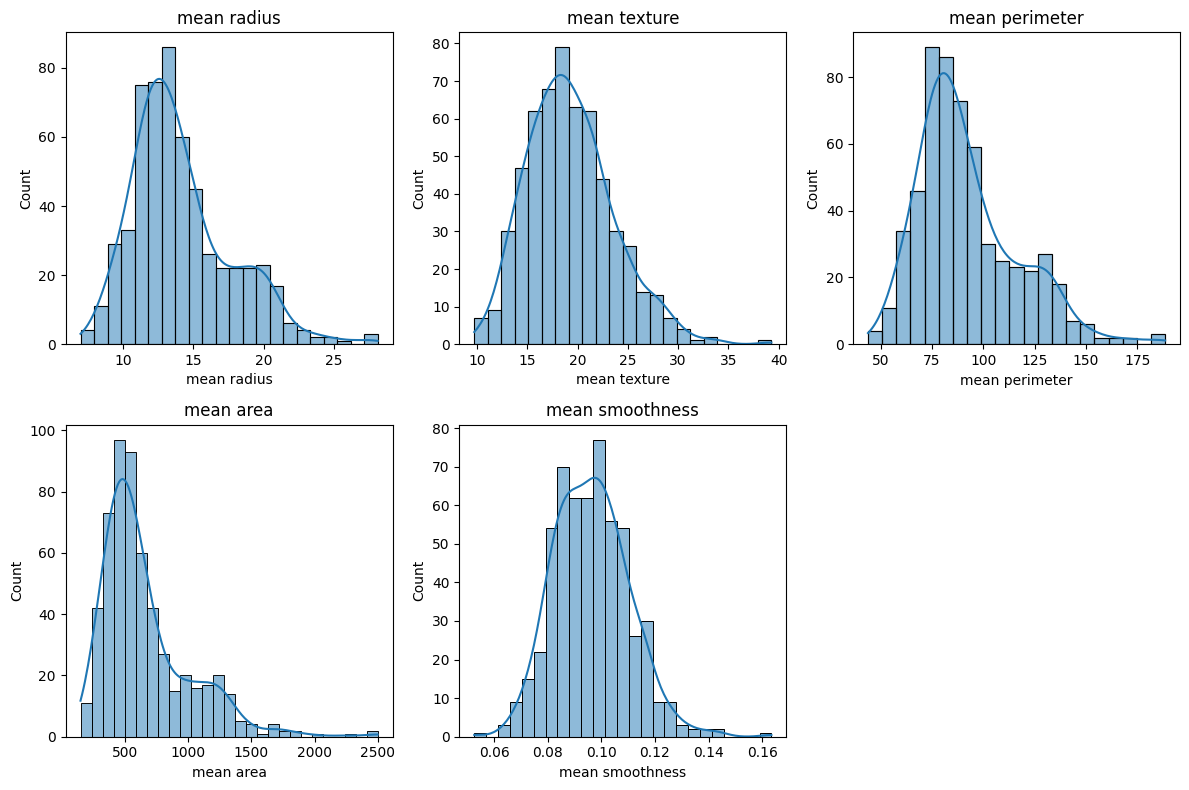


mean:
mean radius         14.127292
mean texture        19.289649
mean perimeter      91.969033
mean area          654.889104
mean smoothness      0.096360
dtype: float64 , 
median:
mean radius         13.37000
mean texture        18.84000
mean perimeter      86.24000
mean area          551.10000
mean smoothness      0.09587
dtype: float64 , 
std:
 mean radius          3.524049
mean texture         4.301036
mean perimeter      24.298981
mean area          351.914129
mean smoothness      0.014064
dtype: float64


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

# Load the breast cancer dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
display(df.head)

# Plot histograms for some of the features
features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[feature], kde=True)
    plt.title(feature)

plt.tight_layout()
plt.show()

print("\nmean:\n{} , \nmedian:\n{} , \nstd:\n {}".format(df[features_to_plot].mean() , df[features_to_plot].median(), df[features_to_plot].std()))

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer


In [5]:

data = load_breast_cancer()
pd.DataFrame(data.data, columns = data.feature_names)
pd.DataFrame(data.target)

,0
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


***
#### Question 2.1 - (10 points)
Analyze each plot and explain your observations regarding these attributes in terms of data skewness (for instance, is the data symmetric, if not is it right/left skewed? Why and how do you identify the skewness by using the parameters of the distributions such as mean, median, standard deviation?) Provide a complete analysis and incude any supporting explanation/computation if relevant.

**_Answer Question 2.1:_** Looking at the pair plot we see that we have the plotted distributions of 5 features this being mean radius, mean texture, mean perimeter. Visually speaking, right off the bat its clear that all the features except for the mean smoothness (which seems to have a symmetric distribution) have a right skew. Now lets look at the mean and median of each feature to identify skew. Typically speaking when the mean is larger than the median it indicates a right skew and for a left skew the mean should be smaller than the median. 
1. Feature 1: _mean radius_
    * mean: 14.127292  > median: 13.37000
    * Mean is greater than median indicating right skew
2. Feature 2: _mean texture_
    * mean: 19.289649 > median: 18.84000
    * Mean is greater than median indicating right skew
3. Feature 3: _mean perimeter_
    * mean: 91.969033 > median: 86.24000
    * Mean is greater than median indicating right skew
4. Feature 4: _mean area_ 
    * mean: 654.889104 > median: 551.10000
    * Mean is greater than median indicating right skew 
5. Feature 5: _mean smoothness_
    * mean: 0.096360 > median: 0.09587
    * Mean is very slightly greater than median idicating a very slight right skew, but could be categorized as an approximately symmetric distribution.

What does this imply? We may have to transform some features, to fit normality assumptions.


***

#### Question 2.2 - (5 points)
Explain and compare the parameters and output of Z-score and Min-Max data transformation techniques. \
\
**_Answer Question 2.2 Answer:_** \
Lets start this comparison by looking at the equations of each respective normalization techniques. \
Min-Max Scaling: $X_{\text{norm}} = \frac{X - X_{\text{min}}}{X_{\text{max}} - X_{\text{min}}}$ \
Z-score transformation: $X_{\text{norm}} = \frac{X - \mu}{\sigma}$\
Looking at the equations we can see a stark difference in the parameters that compose each of the equations. Min-Max Scaling produces a normalized X by subtracting the original value of the feature by the minimum value in the feature all divided by the range of the values in the feature. This returns a normalized value between 0 to 1. This makes it so the data is shifted so the minimum value is 0 and and the maximum value is 1. A disadvantage to using this method of normalization is its sensitivity to outliers sense the formula is dependent on X_min and X_max making it less robust compared to other methods. Z-score normalization transforms the data so that the data as an average of 0 and a standard deviation of 1 through adjusting data values based on how far they deviate from the mean in units of standard deviation. This normalization allows us to work with features that are on different scales where larger scales can dominate smaller scaled features and essetially makes sue all features are treated equally. A disadvantage to using this method of this transformation is the loss of orginal units making interpretability more difficult. 


#### Question 2.3 - (5 points)
Apply the Z-score normalization technique on the dataset. You can either develop the normalization function from scratch, or use sklearn.preprocessing to make function calls to perform the transformation. After data normalization, visualize the normalized attriubutes (note: don't normalize the output variable - apply normalization on these attributes: 'mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness'). Compare the data before and after normalization. What changes you see in the data? 

In [6]:
# Setup
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

data = load_breast_cancer()
df_X = pd.DataFrame(data.data, columns = data.feature_names)
df_Y = pd.DataFrame(data.target)

<mark>**Z-Score Normalization**<mark>

In [7]:
# Applying Z-Score Normalization
scaler = StandardScaler() 

# original data
display(df_X.head())
data = load_breast_cancer()
df_X = pd.DataFrame(data.data, columns = data.feature_names)
df_Y = pd.DataFrame(data.target)

# z-score normalized data
normalized_X_Z = scaler.fit_transform(df_X)
normalized_X_Z_df = pd.DataFrame(normalized_X_Z, columns = data.feature_names)
normalized_X_Z_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


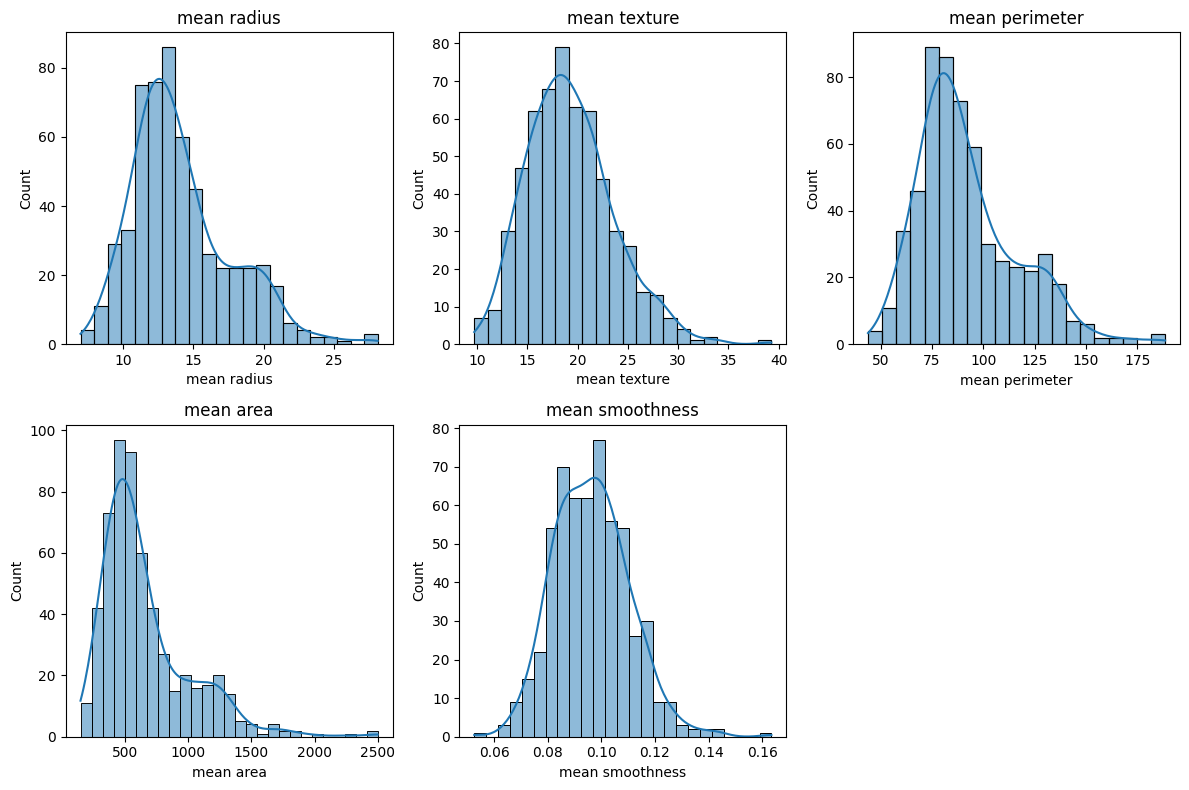


mean:
mean radius         14.127292
mean texture        19.289649
mean perimeter      91.969033
mean area          654.889104
mean smoothness      0.096360
dtype: float64 , 
median:
mean radius         13.37000
mean texture        18.84000
mean perimeter      86.24000
mean area          551.10000
mean smoothness      0.09587
dtype: float64 , 
std:
 mean radius          3.524049
mean texture         4.301036
mean perimeter      24.298981
mean area          351.914129
mean smoothness      0.014064
dtype: float64


In [8]:
# original data plotted distributions pair plot
features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_X[feature], kde=True)
    plt.title(feature)

plt.tight_layout()
plt.show()

print("\nmean:\n{} , \nmedian:\n{} , \nstd:\n {}".format(df_X[features_to_plot].mean() , df_X[features_to_plot].median(), df_X[features_to_plot].std()))

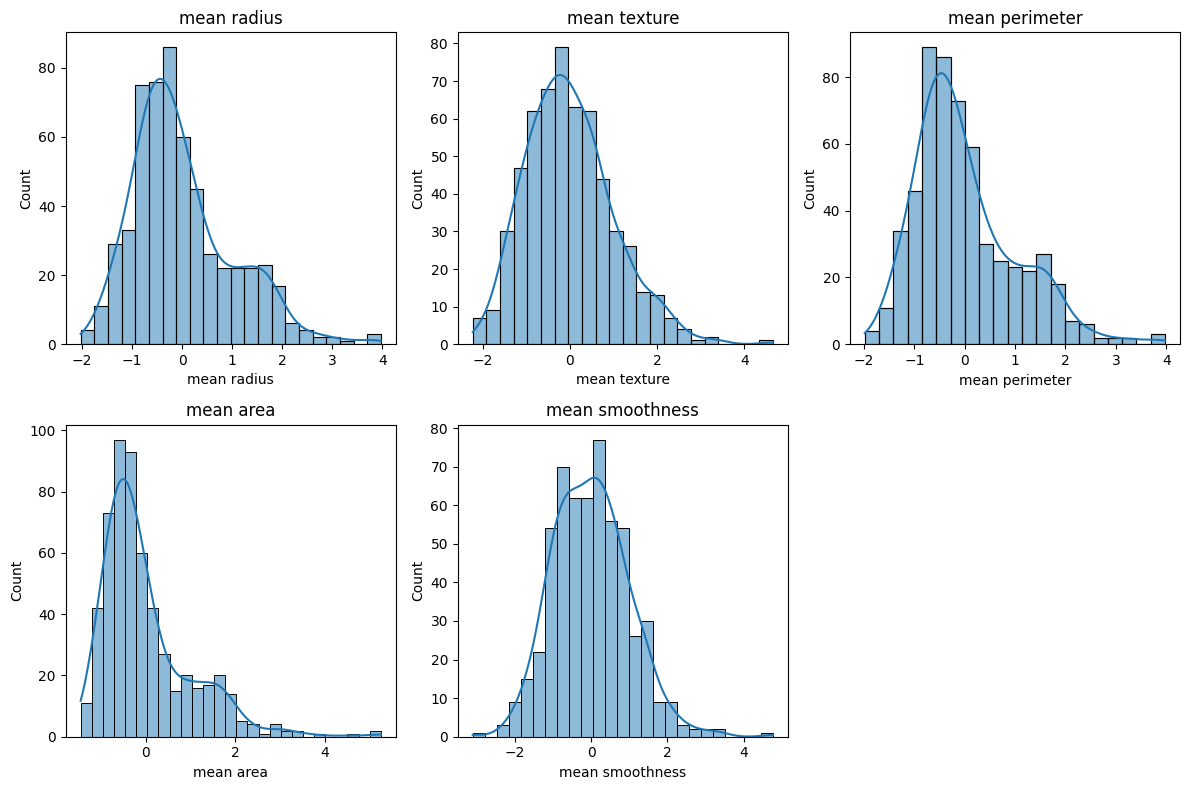


mean:
mean radius       -3.162867e-15
mean texture      -6.530609e-15
mean perimeter    -7.078891e-16
mean area         -8.799835e-16
mean smoothness    6.132177e-15
dtype: float64 , 
median:
mean radius       -0.215082
mean texture      -0.104636
mean perimeter    -0.235980
mean area         -0.295187
mean smoothness   -0.034891
dtype: float64 , 
std:
 mean radius        1.00088
mean texture       1.00088
mean perimeter     1.00088
mean area          1.00088
mean smoothness    1.00088
dtype: float64


In [9]:
# plotting z-score normalized distributions, and z-score normalized metrics
features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(normalized_X_Z_df[feature], kde=True)
    plt.title(feature)

plt.tight_layout()
plt.show()

print("\nmean:\n{} , \nmedian:\n{} , \nstd:\n {}".format(normalized_X_Z_df[features_to_plot].mean() , normalized_X_Z_df[features_to_plot].median(), normalized_X_Z_df[features_to_plot].std()))

`---- Min-Max Scaling Transformation ---- `

In [10]:
# Applying Min-Max Scaling Transformation

# original data
display(df_X.head())

# min-max scaled transformed data 
scalerMM = MinMaxScaler()
normalized_X_MM = scalerMM.fit_transform(df_X)
normalized_X_MM_df = pd.DataFrame(normalized_X_MM, columns = data.feature_names)
normalized_X_MM_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,...,0.620776,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864
1,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.606901,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878
2,0.601496,0.390260,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.509596,0.211247,...,0.556386,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433
3,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.248310,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711
4,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,0.186816,...,0.519744,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595


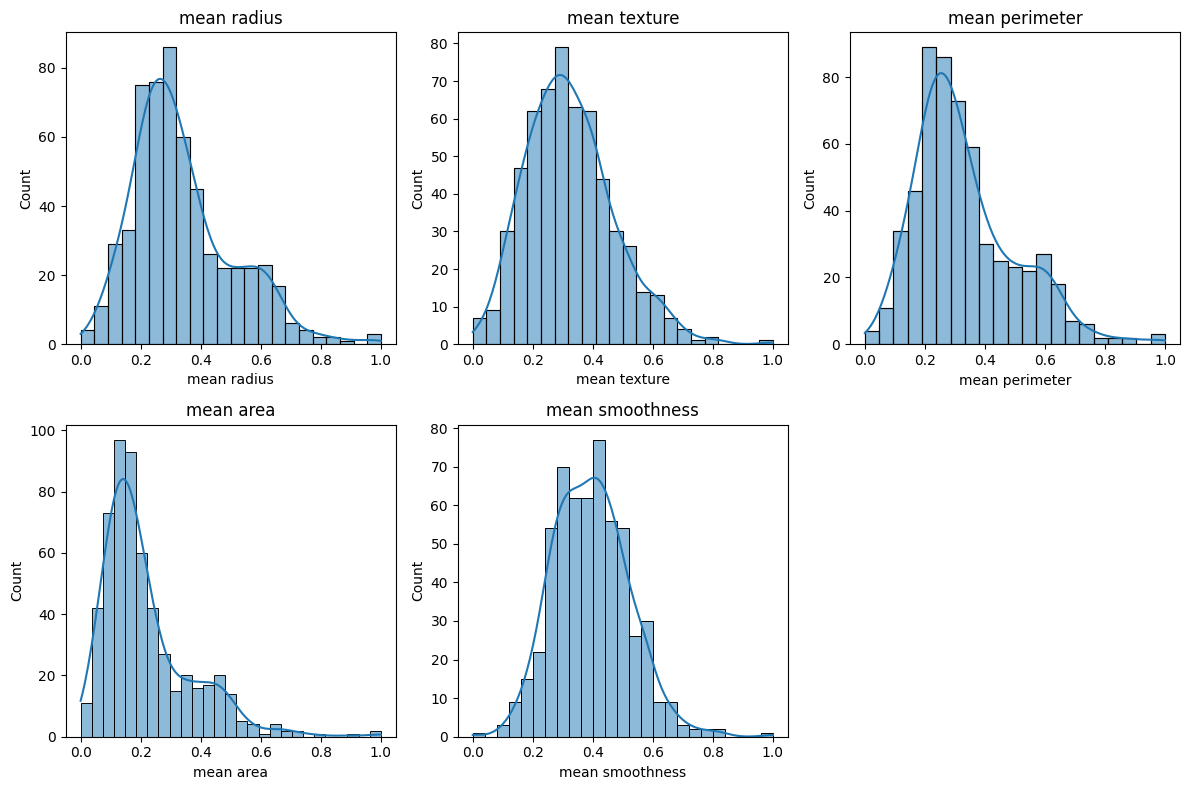


mean:
mean radius        0.338222
mean texture       0.323965
mean perimeter     0.332935
mean area          0.216920
mean smoothness    0.394785
dtype: float64 , 
median:
mean radius        0.302381
mean texture       0.308759
mean perimeter     0.293345
mean area          0.172895
mean smoothness    0.390358
dtype: float64 , 
std:
 mean radius        0.166787
mean texture       0.145453
mean perimeter     0.167915
mean area          0.149274
mean smoothness    0.126967
dtype: float64


In [11]:
# plotting min-max scaled transformed distributions, and min-max scaled transformed metrics
features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(normalized_X_MM_df[feature], kde=True)
    plt.title(feature)

plt.tight_layout()
plt.show()

print("\nmean:\n{} , \nmedian:\n{} , \nstd:\n {}".format(normalized_X_MM_df[features_to_plot].mean() , normalized_X_MM_df[features_to_plot].median(), normalized_X_MM_df[features_to_plot].std()))

**_Written Answer Question 2.3:_** \
In the above section we apply Z-score normalization and Min-Max scaling. But I will only be discussing the effects on the data before and after Z-Score normalization.\
Visually speaking there is slight to no difference in the distributions of each feature, with the only visible difference being a difference in the x-scale. Now lets take a closer look at our z-score normalized values. Looking at the skews of each feature using the comparison between the mean median we see that 
1. Feature 1: _mean radius_
    * **| original |** mean : 14.127292  > median: 13.37000
    * **| transformed |** mean: -3.162867e-15 > median: -0.215082
    * Mean is still greater than median indicating right skew
2. Feature 2: _mean texture_
    * **| original |** mean: 19.289649 > median: 18.84000
    * **| transformed |** mean: -6.530609e-15  > median: -0.104636
    * Mean is still greater than median indicating right skew
3. Feature 3: _mean perimeter_
    * **| original |** mean: 91.969033 > median: 86.24000
    * **| transformed |** mean: -7.078891e-16  > median: -0.235980
    * Mean is still greater than median indicating right skew
4. Feature 4: _mean area_ 
    * **| original |** mean: 654.889104 > median: 551.10000
    * **| transformed |** mean: -8.799835e-16  > median: -0.295187
    * Mean is still greater than median indicating right skew 
5. Feature 5: _mean smoothness_
    * **| original |** mean: 0.096360 > median: 0.09587
    * **| transformed |** mean: 6.132177e-15 > median: -0.034891
    * The difference between the mean and median seems to actually be greater in the transformed version which is interesting. Either way the mean is still slightly larger than the median idicating a very slight right skew, but could be categorized as an approximately symmetric distribution.

Overall, it just seems that the data has been downscaled so that all of them are in aorund the same range of values which means it is serving itspurpose in treating each feature equally. However it seems that the right skew still exists.
***

#### Question 2.4 - (5 points)
Find the outliers in the data (for the identified attributes) if any, by computing the interquartile ranges for Q1, Q2, Q3, IQR, min and max. Also visualize the outliers if any. 
***

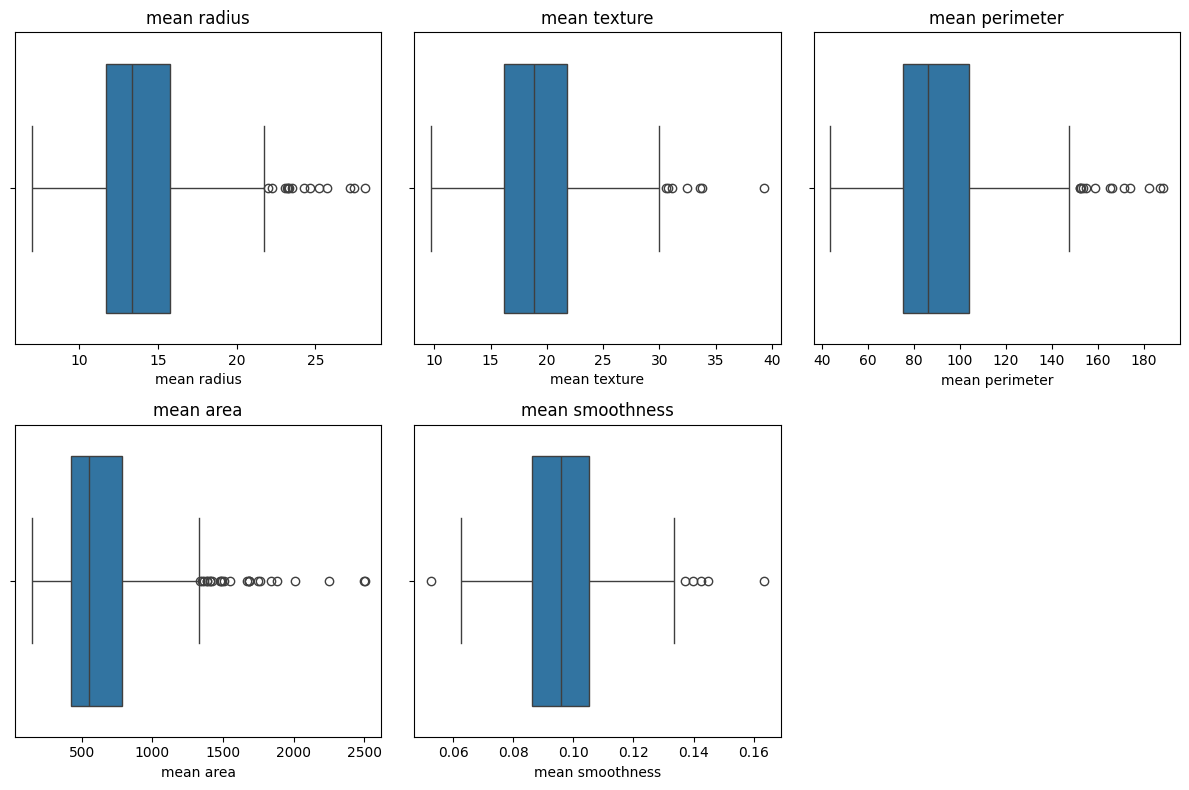


Feature: mean radius
Quartile 1:
11.7 , 
Quartile 2:
13.37 , 
Quartile 3:
15.78, 
Interqartile Range:
4.08,
Lower Fence:
5.579999999999999, 
Upper Fence:
21.9 

Feature: mean texture
Quartile 1:
16.17 , 
Quartile 2:
18.84 , 
Quartile 3:
21.8, 
Interqartile Range:
5.629999999999999,
Lower Fence:
7.725000000000003, 
Upper Fence:
30.244999999999997 

Feature: mean perimeter
Quartile 1:
75.17 , 
Quartile 2:
86.24 , 
Quartile 3:
104.1, 
Interqartile Range:
28.929999999999993,
Lower Fence:
31.775000000000013, 
Upper Fence:
147.49499999999998 

Feature: mean area
Quartile 1:
420.3 , 
Quartile 2:
551.1 , 
Quartile 3:
782.7, 
Interqartile Range:
362.40000000000003,
Lower Fence:
-123.30000000000001, 
Upper Fence:
1326.3000000000002 

Feature: mean smoothness
Quartile 1:
0.08637 , 
Quartile 2:
0.09587 , 
Quartile 3:
0.1053, 
Interqartile Range:
0.018930000000000002,
Lower Fence:
0.057975, 
Upper Fence:
0.133695 


In [12]:
features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(df_X[feature], orient = 'h')
    plt.title(feature)

plt.tight_layout()
plt.show()

for i, feature in enumerate(features_to_plot, 1):
    print(f"\nFeature: {feature}")
    print("Quartile 1:\n{} , \nQuartile 2:\n{} , \nQuartile 3:\n{}, \nInterqartile Range:\n{},\nLower Fence:\n{}, \nUpper Fence:\n{} "
      .format(np.percentile(df_X[feature],25),
              np.percentile(df_X[feature],50), 
              np.percentile(df_X[feature],75),
              np.percentile(df_X[feature],75) - np.percentile(df_X[feature],25),
              (np.percentile(df_X[feature],25)) - (1.5 * (np.percentile(df_X[feature],75) - np.percentile(df_X[feature],25))),
              (np.percentile(df_X[feature],75)) + (1.5 * (np.percentile(df_X[feature],75) - np.percentile(df_X[feature],25)))
            )
    )

In [13]:
# lets extract outliers using sql queries to df
from pandasql import sqldf

outliers_radius = """
SELECT `mean radius`
FROM df_X
WHERE `mean radius` > 21.9  OR `mean radius` < 5.579999999999999
"""
outliers_texture = """
SELECT `mean texture`
from df_X
WHERE `mean texture` > 30.244999999999997 OR `mean texture` < 7.725000000000003
"""
outliers_perimeter= """
SELECT `mean perimeter`
from df_X
WHERE `mean perimeter` > 147.49499999999998 OR `mean perimeter` < 31.775000000000013
"""
outliers_area = """ 
SELECT `mean area`
from df_X
WHERE `mean area` > 1326.3000000000002 OR `mean area` < -123.30000000000001
"""
outliers_smoothness = """
SELECT `mean smoothness`
from df_X
WHERE `mean smoothness` > 0.133695 OR `mean smoothness` < 0.057975
"""

outliers_radius_df = sqldf(outliers_radius, globals())
outliers_texture_df = sqldf(outliers_texture, globals())
outliers_perimeter_df = sqldf(outliers_perimeter, globals())
outliers_area_df = sqldf(outliers_area, globals())
outliers_smoothness_df = sqldf(outliers_smoothness, globals())


display(outliers_radius_df)
display(outliers_texture_df)
display(outliers_perimeter_df)
display(outliers_area_df)
display(outliers_smoothness_df)

,mean radius
0,25.22
1,22.27
2,24.25
3,23.27
4,27.22
5,23.29
6,28.11
7,23.21
8,23.51
9,25.73


,mean texture
0,32.47
1,33.81
2,39.28
3,33.56
4,31.12
5,30.72
6,30.62


,mean perimeter
0,171.5
1,152.8
2,166.2
3,152.1
4,182.1
5,158.9
6,188.5
7,153.5
8,155.1
9,174.2


,mean area
0,1404.0
1,1878.0
2,1509.0
3,1761.0
4,1686.0
5,2250.0
6,1685.0
7,2499.0
8,1670.0
9,1364.0


,mean smoothness
0,0.14250
1,0.13980
2,0.14470
3,0.16340
4,0.13710
5,0.05263


### Question 3 (Linear Regression) - (20 points)
For this question, use the [California House Prices dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html) from sklearn. The goal is to develop a linear regression model to predict the target variable (MedHouseVal) which represents the median house value for California districts, expressed in hundreds of thousands of dollars ($100,000). Note that the precision of changes to look for in this dataset may be relatively small so keep an eye out for smaller changes in the difference between models - in the range of around 2 percent or more between models.

#### Question 3.1 - (5 points)
Split your data into train and test sets by [80:20] rate (80\% for training and 20\% for testing). Initialize a LinearRegression model using the LinearRegression algorithm in sklearn. Evaluate the performance of the model on the test data by reporting MSE and R2 values (you can call the existing functions in sklearn to report MSE and R2, or you can develop these techniques from scratch). Visualize the relatioship between y and y_hat in test data (see the example plot covered during lecture).
***

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt 
from sklearn.model_selection import KFold


In [15]:
data = fetch_california_housing()
X = data.data
y = data.target

In [16]:

X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=42)
model_unscaled = LinearRegression()
model_unscaled.fit(X_train, y_train)
y_train_pred = model_unscaled.predict(X_train)
y_test_pred = model_unscaled.predict(X_test)

mse_unscaled = mean_squared_error(y_test, y_test_pred)
r2_unscaled = r2_score(y_test, y_test_pred)

print(f"\nMSE = {mse_unscaled}")
print(f"\nR2 = {r2_unscaled}")


MSE = 0.5558915986952423

R2 = 0.5757877060324523


/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered

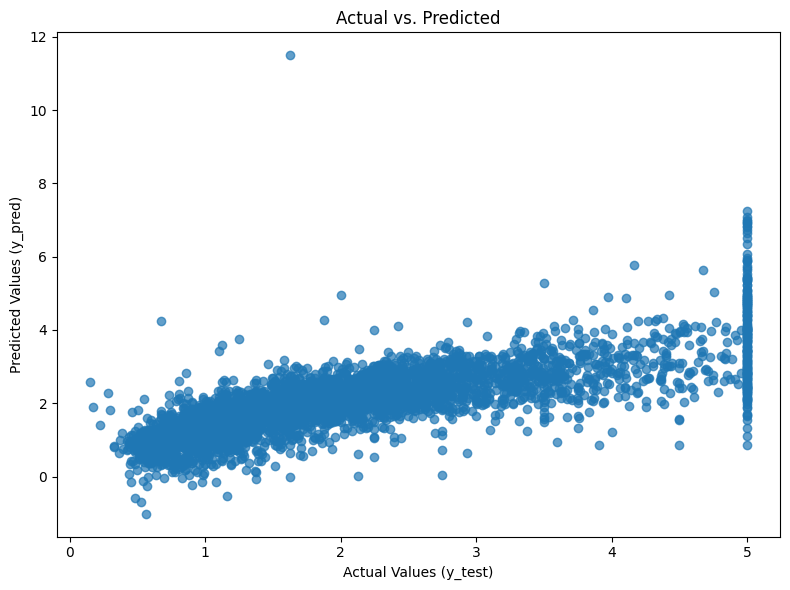

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("Actual vs. Predicted")
plt.tight_layout()
plt.show()

***
#### Question 3.2 - (5 points)
Repeat 3.1 using the normalized features to train your model (use z-score). Compare your findings from 3.1 and 3.2 and report any observations. 


In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

y_train_pred_scaled = model_scaled.predict(X_train_scaled)
y_test_pred_scaled = model_scaled.predict(X_test_scaled)

mse_scaled = mean_squared_error(y_test, y_test_pred_scaled)
r2_scaled = r2_score(y_test, y_test_pred_scaled)

print(f"\nMSE = {mse_scaled}")
print(f"\nR2 = {r2_scaled}")


MSE = 0.5558915986952444

R2 = 0.5757877060324508


/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered

In [20]:
print(model_scaled.coef_)
print(model_unscaled.coef_)

[ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]
[ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]


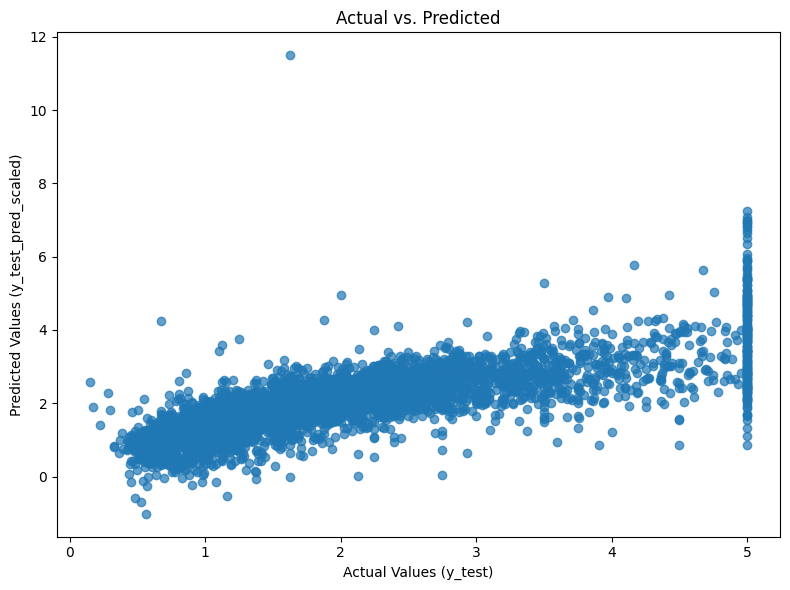

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred_scaled, alpha=0.7)
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_test_pred_scaled)")
plt.title("Actual vs. Predicted")
plt.tight_layout()
plt.show()

***
#### Question 3.3 - (10 points)
Implement cross validation method (from scratch), and apply 12-fold cross validation on your model to enhance the fit of your model. Report the mean of the R2 and MSE scores as the mse and R2 of the best model. Print the coefficients (i.e., weights) of the best model and explain what do you consider to be the best model. 

In [22]:

data = fetch_california_housing()
X = data.data
y = data.target

folds = 12
kf = KFold(folds)
r2_values = []
mse_values = []
models_coefs = []


for train_index, test_index in kf.split(X):
        # Split data into training and testing sets for this fold
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Fit polynomial regression model
        model = LinearRegression()
        model.fit(X_train, y_train)

        # Make predictions on the test set
        y_pred = model.predict(X_test)

        # Calculate variance and bias for this fold
        r2_value = r2_score(y_test, y_pred)
        mse_value = mean_squared_error(y_test, y_pred)
        model_coef= model.coef_
        
        # Append results to lists
        r2_values.append(r2_value)
        mse_values.append(mse_value)
        models_coefs.append(model_coef)

        # Print results for this fold
        print("\nR2: {:.4f}, MSE: {:.4f}".format(r2_value, mse_value))
        print(pd.DataFrame(model_coef))



/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered


R2: 0.5746, MSE: 0.4062
          0
0  0.435915
1  0.010382
2 -0.106880
3  0.657364
4 -0.000005
5 -0.003774
6 -0.439798
7 -0.465729

R2: -0.7375, MSE: 0.4638
          0
0  0.438915
1  0.009571
2 -0.119015
3  0.760987
4 -0.000008
5 -0.004241
6 -0.419434
7 -0.438150

R2: 0.4010, MSE: 0.7438
          0
0  0.431787
1  0.009575
2 -0.090758
3  0.568221
4 -0.000007
5 -0.003499
6 -0.416835
7 -0.433520

R2: 0.4732, MSE: 0.7489
          0
0  0.431385
1  0.008583
2 -0.099642
3  0.607875
4 -0.000005
5 -0.003491
6 -0.413276
7 -0.435587

R2: 0.3717, MSE: 0.3797
          0
0  0.434140
1  0.010589
2 -0.107600
3  0.642077
4 -0.000003
5 -0.003579
6 -0.427971
7 -0.433174

R2: 0.5723, MSE: 0.7680
          0
0  0.430233
1  0.009115
2 -0.100278
3  0.603641
4  0.000002
5 -0.003554
6 -0.423232
7 -0.440749

R2: 0.5088, MSE: 0.5514
          0
0  0.443953
1  0.009939
2 -0.119537
3  0.683691
4  0.000002
5 -0.003714
6 -0.424700
7 -0.437486

R2: 0.4414, MSE: 0.2599
          0
0  0.441646
1  0.010369
2 -0.11

/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/FM/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered

For the best model I was looking for a balance between R^2 values and the MSE values. Ideally we want a lower MSE and the highest R^2. But of course looking at the 12 folds we see that theres no distinct model with both these features. But I think looking at all of the models the one with a balance of R2 and MSE values is the first fold model with a R2 of 0.5746 and MSE of 0.4062.

***
### Question 4- (20 points)
Answer the following questions:

#### Question 4.1 - (3 points)
What is the difference between Gradient Descent and Ordinary Lease Squares method? Explain the advantages and disadvantages of each approach. \
\
**_Answer Question 4.1:_** The OLS method calculates the coefficients of the linear regression model directly through the equation $$w = X^tY(X^tX)^{-1}$$. But the disadvantages are that this method only works when $(X^tX)^{-1}$ is invertible which sometimes doesn't occur especially when theirs perfect multicollinearity among features in a dataset making $(X^tX)^{-1}$ non-invertible. This makes this method not very suitable for large datasets, and only works for linear relationships but an advantage is that you can compute it directly so no updates , no loops, and no convergence criteria. The gradient descent method is more flexible and scalable and is an iterative approach to finding model weights. It uses weight update rule to apply weight changes but it could be computationally heavy considering the learning rate you choose and there's no garuntee that it'll give the optimal solution.

***

#### Question 4.2 - (2 points)
How does a negative or positive gradient indicate the direction towards achieving a sub-optimal or optimal weight? Explain your answer. \
\
**_Answer Question 4.:_** The gradient descent alorithm aims to differentiate our cost function at different points of the line so we can derive the degree of change in direction at these specific points thus enabling us to take steps towards the steepest descent which is the local minimum.
Since we want to minimize the cost function the gradient descent moves in the opposite direction of the gradient which is the negative gradient direction achieving the optimal weight and if we were to go in the positive direction we wuld reach the sub-optimal weight.

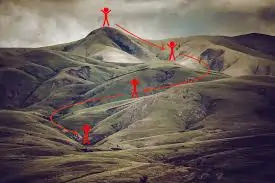

***

#### Question 4.3 - (10 points)
Provide the complete math for updating Wj associated with the jth attribute of a dataset using Gradient Descent weight update rule for finding the coefficients of a linear regression model. Use the Sum of Squared Residuals (SSR) as the loss (or cost) function to compute the gradient (i.e., weight change). Provide all the necessary details explaining the parameters used in your work. \
\
**Model Prediction for Obs:**
$$
\hat{y}^{(i)} = \sum_{k=0}^m w_k x_k^{(i)} = w^T x^{(i)}
$$

**Loss (RSS) for Single Obs:**
$$
\text{Loss}_i = \left( y^{(i)} - \hat{y}^{(i)} \right)^2
$$

**Gradient with Respect to \(w_j\):**
$$
\frac{\partial \text{RSS}_i}{\partial w_j} = \frac{\partial}{\partial w_j} \left( y^{(i)} - \sum_{k=0}^m w_k x_k^{(i)} \right)^2
$$
Chain rule:
$$
\frac{\partial \text{RSS}_i}{\partial w_j} = -2 \left( y^{(i)} - \sum_{k=0}^m w_k x_k^{(i)} \right) x_j^{(i)}
$$

**Gradient Descent Update:**
$$
w_j^{\text{new}} = w_j^{\text{old}} - \alpha \frac{\partial \text{RSS}_i}{\partial w_j}
$$
Substitute the gradient:
$$
\boxed{w_j^{\text{new}} = w_j^{\text{old}} + 2\alpha \left( y^{(i)} - \sum_{k=0}^m w_k x_k^{(i)} \right) x_j^{(i)}}
$$

***

#### Question 4.4 - (5 points)
Explain the strategy in and the difference between stochastic gradient descent and batch-gradient descent algorithmically. \
\
**_Answer 4.4:_** Batch Gradient Descent calculates is the gradient of the cost function using the  training dataset for each iteration. This approach makes it so that the gradient is precise but is more computationally expensive. Stochastic Gradient Descent computes the gradient using only a single training example or a small subset for each iteration which makes this algorithm faster. But the disadvantage is that it may not converge exactly at the global minimum.


***

### Question 5 (Stochastic Gradient Descent)- (10 points)
Use California House Prices dataset for this question.  
Use stochastic gradient descent approach to train a linear regression model using all the features of the dataset. After each epoch of training, record the MSE and R2 scores of the linear regression model on training data and test data. Run your solution for 100 epochs. Plot the recorded MSE-train[], MSE-test in one figure, and R2-train[], R2-test in another figure (over 100 epochs).  Annotate your code. Explain the details of your understanding of the code below the code or in the following markdown cell.


In [23]:
housing = fetch_california_housing()
X = housing.data  # Features (8 features)
y = housing.target  # Target variable (median house value in $100,000s)

# split training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# standardize training data mean=0, std=1, using z-score standardization
# why do we do this? features have different units so we want to keep them on the same scale
# only applying fit to training data but transforming both data 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# addding the  bias term
X_train_bias = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_bias = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

# n number of features + 1 for the bias term, we initialize model with random values
np.random.seed(42) 
n_features = X_train_scaled.shape[1]
theta = np.random.randn(n_features + 1, 1) * 0.01  #this is our small random initialization
learning_rate = 0.0001  # this is our step size for our gradient updates
epochs = 100  # this is the number of passes through training set, one epoch is one pass
batch_size = 32  # this is the size of mini-batches that we will be using for  gradient computation

# this is where we are storing the metrics we want to calculate for each epoch
mse_train_history = []
mse_test_history = []
r2_train_history = []
r2_test_history = []

In [24]:

for epoch in range(epochs):
    # shuffle training data for epoch
    m = X_train_bias.shape[0]  # the number of training samples we have
    indices = np.random.permutation(m)
    X_shuffled = X_train_bias[indices]
    y_shuffled = y_train[indices].reshape(-1, 1)  # reshaping y to make sure its a column vector
    
    # Processing training data in mini-batches
    for i in range(0, m, batch_size):
        # mini-batch
        X_batch = X_shuffled[i:i + batch_size]
        y_batch = y_shuffled[i:i + batch_size]
        
        # compute predictions for this batch
        predictions_batch = X_batch.dot(theta)
        
        #  gradient of MSE loss for this batch
        error_batch = predictions_batch - y_batch
        gradients = (2 / len(X_batch)) * X_batch.T.dot(error_batch)
        
        # updating our weights using our learning rate and gradients
        theta -= learning_rate * gradients
    
    # after we are through every epoch evaluate on training and testing sets
    
    # training set predictions and metrics
    y_train_pred = X_train_bias.dot(theta)
    mse_train = mean_squared_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)
    
    # test set predictions and metrics
    y_test_pred = X_test_bias.dot(theta)
    mse_test = mean_squared_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    mse_train_history.append(mse_train)
    mse_test_history.append(mse_test)
    r2_train_history.append(r2_train)
    r2_test_history.append(r2_test)
    
    # every 10 epochs print metrics
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}: " f"Train MSE = {mse_train:.4f}, Test MSE = {mse_test:.4f} || "f"Train R2 = {r2_train:.4f}, Test R2 = {r2_test:.4f}")

print("\nfinal model:")
print(f"Training MSE: {mse_train_history[-1]:.4f}")
print(f"Testing MSE:  {mse_test_history[-1]:.4f}")
print(f"Training R2:  {r2_train_history[-1]:.4f}")
print(f"Testing R2:   {r2_test_history[-1]:.4f}")
print(f"Model parameters:\n{theta.flatten()}")

Epoch   0: Train MSE = 4.6780, Test MSE = 4.6022 || Train R2 = -2.4994, Test R2 = -2.5121
Epoch  10: Train MSE = 1.1487, Test MSE = 1.1449 || Train R2 = 0.1407, Test R2 = 0.1263
Epoch  20: Train MSE = 0.6864, Test MSE = 0.6944 || Train R2 = 0.4865, Test R2 = 0.4701
Epoch  30: Train MSE = 0.6137, Test MSE = 0.6246 || Train R2 = 0.5409, Test R2 = 0.5234
Epoch  40: Train MSE = 0.5931, Test MSE = 0.6053 || Train R2 = 0.5563, Test R2 = 0.5381
Epoch  50: Train MSE = 0.5810, Test MSE = 0.5943 || Train R2 = 0.5654, Test R2 = 0.5464
Epoch  60: Train MSE = 0.5714, Test MSE = 0.5860 || Train R2 = 0.5725, Test R2 = 0.5528
Epoch  70: Train MSE = 0.5635, Test MSE = 0.5793 || Train R2 = 0.5785, Test R2 = 0.5579
Epoch  80: Train MSE = 0.5567, Test MSE = 0.5739 || Train R2 = 0.5835, Test R2 = 0.5620
Epoch  90: Train MSE = 0.5510, Test MSE = 0.5696 || Train R2 = 0.5878, Test R2 = 0.5654

final model:
Training MSE: 0.5466
Testing MSE:  0.5663
Training R2:  0.5911
Testing R2:   0.5679
Model parameters:
[ 

(0.0, 100.0)

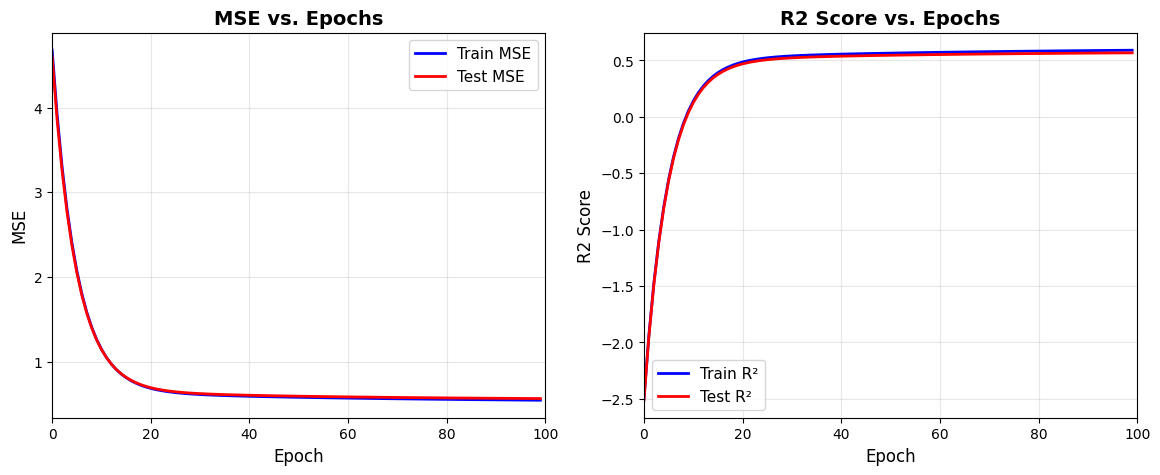

In [ ]:
# plotting the results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(epochs), mse_train_history, 'b-', label='Train MSE', linewidth=2)
axes[0].plot(range(epochs), mse_test_history, 'r-', label='Test MSE', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE', fontsize=12)
axes[0].set_title('MSE vs. Epochs', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, epochs])

axes[1].plot(range(epochs), r2_train_history, 'b-', label='Train R²', linewidth=2)
axes[1].plot(range(epochs), r2_test_history, 'r-', label='Test R²', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('R2 Score', fontsize=12)
axes[1].set_title('R2 Score vs. Epochs', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, epochs])


***
### Question 6 (Ridge and Lasso Regression)- (8 points)

#### Question 6.1-(4 points)
Compare the cost functions in Ridge and Lasso Regression and indicate the regularization parameter.\
\
**_Answer 6.1:_** The cost functions for both ridge and lasso are essentially the same besides their penalties. Lasso regression uses the penalty of sum the absolute of the magnitude of the coeffieicints multiplied the the penalty term lambda which helps by shrinking some weights to be 0 thus regularizing the model. In ridge regression the penalty is the sum of the square of the magnitude of the coefficients multiplies the penalty term whe're large weights are penalized more.
***



#### Question 6.2-(4 points) 
Explain which weights are more penalized in Ridge Regression and why (discuss your answer in the context of constraint satisfaction and take into account the constraint on Ridge Regression coefficients). \
\
**_Answer 6.2:_** Larger weights are penalized more. This is because the penalty uses the sum of the square which makes it a quadratic penalty that grows faster for larger values, thus affecting larger weights more than smaller ones
***

### Question 7 (MLE)- (12 points)
In the context of training a linear regression model using Maximum-Likelihood-Estimation, answer the following questions:


#### Question 7.1-(4 points) 
Indicate all assumptions discussed in the lecture under the MLE principle about the data, residual error, and the type of the probability density function used in the Likelihood function. \
\
**_Answer 7.1:_**: Key assumptions include...
* $x_0 = 1$
* $x_1, x_2, ..., x_m$ are independent variables and y is the dependent variables 
* $\epsilon$: residual error term with $\epsilon\sim N(0, \sigma^2)$ where $\sigma^2$ is a constant
and $\epsilon$ is independent across observations and normally distributed. \
\
The PDF is Gaussian.
***

#### Question 7.2-(4 points) 
Indicate the Likelihood function mathematically with respect to the assumptions made under MLE principle, and describe each term/parameters used in the likelihood function. \
\
$
L(w_0, w_1, \dots, w_m, \sigma^2 \mid x, y) = \prod_{i=1}^n \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(y_i - g(x_i))^2}{2\sigma^2} \right)
$
Likelihood function L represents the joing probability distribution of observed data $X_1, ..., X_n$. It is the product of the likelohoodd of observing data given we have the weights of the linear regression model $w_0 .... w_m$ and the spread which is $\sigma^2$.  The error has a gaussian distribution so the PDF has the form of said gaussian distribution to measure the likelihood of observing data within a certain range...\
$PDF(X) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(y_i - g(x_i))^2}{2\sigma^2} \right)$ \

$\sigma^2$ is the variance of the errors in the linear regression model \
The mean of the PD of data which is variable y is represented by the linear combination of the predictior variables and the coefficients in the regression model. \
PD of data is PDF(X)
***

#### Question 7.3-(4 points) 
Explain how the concept of maximizing the likelihood of observing data under model parameters is convertible to minimizing the NLL? Discuss in terms of the mathematical notation and the shape of the function. 

Maximizing the likelihood of observing the data under midel parameters is convertible to minimizing the NLL because the logarithmic function is an increasing function thus the negatbe sign reverse the optimization direction. Mathematically speaking if negative log likelihood is written as $-L(X \mid \theta)$ as a function of $\theta$ where theres a minimum at $\theta_{min}$.\
Extended. That means for any $\theta_{i}$, $-L(X \mid \theta_{min}) \leq -L(X \mid \theta_i)$ multiply both sides and you get 
$$L(X \mid \theta_{min}) \geq L(X \mid \theta_i)$$
Thus showing the maximizing of $L(X \mid \theta)$ over $\theta$.
